In [ ]:
import os
import shutil
import pandas as pd
import json
from collections import defaultdict

In [ ]:
def move_matched_folders(csv_file, source_folder, destination_folder):
    # Load the CSV file
    df = pd.read_csv(csv_file)
    
    # Get the unique list of Image Filenames from the CSV file
    matched_folders = df['Image Filename'].unique()

    # Create the destination folder if it doesn't exist
    os.makedirs(destination_folder, exist_ok=True)

    # Iterate over each folder in the source directory
    for folder_name in os.listdir(source_folder):
        # Check if the folder name matches any entry in the CSV file's Image Filename column
        if folder_name in matched_folders:
            # Move the folder to the destination path
            source_path = os.path.join(source_folder, folder_name)
            destination_path = os.path.join(destination_folder, folder_name)
            shutil.move(source_path, destination_path)
            print(f"Moved folder: {folder_name}")

    print(f"All matched folders moved to {destination_folder}")

In [ ]:
csv_file = '/Users/hamza/Research/Muharaf/Dataset/merged_writer.csv'
source_folder = '/Users/hamza/Research/Muharaf/Lines'
destination_folder = '/Users/hamza/Research/Muharaf/Dataset/Lines_'
move_matched_folders(csv_file, source_folder, destination_folder)

Moved folder: kc0061_01_04_19210412_001b
Moved folder: SB1A_01r
Moved folder: kc0066_01_01_1873diary_064
Moved folder: AR56_01_049
Moved folder: MK2A_07_18r
Moved folder: AF_321r
Moved folder: JPK2B_53_01
Moved folder: ST1A_197_24
Moved folder: EAC_A_039_062r
Moved folder: Nasrallah-Al001-034q
Moved folder: kc0066_01_01_1873diary_063
Moved folder: AR56_03_012
Moved folder: ST1A_197_23
Moved folder: TAttallah2020-077
Moved folder: HM1B_04_15r
Moved folder: kc0066_01_01_1873diary_055
Moved folder: ST1A_197_15
Moved folder: AR56_01_047
Moved folder: kc0061_01_03_19201109_001
Moved folder: AR56_03_024
Moved folder: EAK1A_154_02v
Moved folder: YFS5A_09r
Moved folder: YS_5H_023a
Moved folder: kc0066_01_01_1873diary_052
Moved folder: MUKF7I_01_019r
Moved folder: KEllis2020-140d
Moved folder: AF_279r
Moved folder: AR56_03_023
Moved folder: YAL2A_40
Moved folder: ST1A_197_12
Moved folder: YS_1E_005a
Moved folder: kc0066_01_01_1873diary_039
Moved folder: Nasrallah-Al001-034j
Moved folder: AR56_0

In [ ]:
def copy_matched_xml_files(csv_file, source_folder_has, source_folder_no, destination_folder):
    # Load the CSV file
    df = pd.read_csv(csv_file)
    
    # Get the unique list of Image Filenames from the CSV file
    matched_files = df['Image Filename'].unique()

    # Create the destination folder if it doesn't exist
    os.makedirs(destination_folder, exist_ok=True)

    # Define source folders
    source_folders = [source_folder_has, source_folder_no]

    # Iterate through each source folder
    for source_folder in source_folders:
        # Iterate over each file in the source folder
        for file_name in os.listdir(source_folder):
            # Check if the file has an .xml extension
            if file_name.endswith('.xml'):
                # Check if the file name (without extension) matches any entry in the CSV
                file_base_name = os.path.splitext(file_name)[0]
                if file_base_name in matched_files:
                    # Copy the file to the destination path
                    source_path = os.path.join(source_folder, file_name)
                    destination_path = os.path.join(destination_folder, file_name)
                    shutil.copy2(source_path, destination_path)
                    print(f"Copied file: {file_name}")

    print(f"All matched XML files copied to {destination_folder}")

In [ ]:
csv_file = '/Users/hamza/Research/Muharaf/Dataset/merged_writer.csv'
source_folder_has = '/Users/hamza/Research/Muharaf/has_writer'
source_folder_no = '/Users/hamza/Research/Muharaf/no_writer'
destination_folder = '/Users/hamza/Research/Muharaf/Dataset/Lines_XML'
copy_matched_xml_files(csv_file, source_folder_has, source_folder_no, destination_folder)

Copied file: EAK1A_150_01v.xml
Copied file: EAK1A_158v.xml
Copied file: EAK1A_144_02r.xml
Copied file: JoM_Kobayat_0075.xml
Copied file: EAK1A_154_02r.xml
Copied file: HM1B_10_29v.xml
Copied file: EAK1A_289r.xml
Copied file: JEH2F1_30_01r.xml
Copied file: HM1B_10_05v.xml
Copied file: MUKF4A_01_002r.xml
Copied file: YFS2A_02_02_2.xml
Copied file: HM1B_10_04r.xml
Copied file: JoM_Kobayat_0074.xml
Copied file: HM1B_04_10r.xml
Copied file: HM1B_04_11v.xml
Copied file: JoM_Kobayat_0128.xml
Copied file: HM1B_04_07v.xml
Copied file: SB2A_01v.xml
Copied file: YFS5A_09r.xml
Copied file: SB1A_09r.xml
Copied file: MeM1D_02_004r.xml
Copied file: EAK1A_088r.xml
Copied file: AnF_010.xml
Copied file: EAK1A_090_01r.xml
Copied file: EAK1A_067r.xml
Copied file: MUKF4A_02_085r.xml
Copied file: AnF_006.xml
Copied file: MUKF4A_02_084v.xml
Copied file: BEK2A_17_02r.xml
Copied file: JEH2A2_18.xml
Copied file: YS_4C_069.xml
Copied file: EAK1A_180r.xml
Copied file: YS_4C_068.xml
Copied file: JEH2A2_19.xml
Copi

In [ ]:
import xml.etree.ElementTree as ET

def extract_arabic_handwritten(xml_file):
    # Parse the XML file
    tree = ET.parse(xml_file)
    root = tree.getroot()

    # Set up namespace for PAGE XML
    ns = {"ns": "http://schema.primaresearch.org/PAGE/gts/pagecontent/2019-07-15"}

    # Extract lines with Arabic, handwritten-cursive attributes
    arabic_lines = []
    for text_region in root.findall(".//ns:TextRegion", ns):
        for text_line in text_region.findall(".//ns:TextLine", ns):
            primary_language = text_line.get("primaryLanguage")
            production = text_line.get("production")
            
            # Check if line is Arabic and handwritten-cursive
            if primary_language == "Arabic" and production == "handwritten-cursive":
                # Extract the actual text content
                text_equiv = text_line.find(".//ns:TextEquiv/ns:Unicode", ns)
                if text_equiv is not None:
                    arabic_lines.append(text_equiv.text.strip())

    # Print each line in the order found
    print("Extracted Arabic handwritten-cursive lines:")
    for line in arabic_lines:
        print(line)

In [ ]:
xml_file = "/Users/hamza/Research/Muharaf/Dataset/Lines_XML/TAttallah2020-020.xml"
extract_arabic_handwritten(xml_file)

Extracted Arabic handwritten-cursive lines:
ابهىَّ السلام. ومن خصوصي وخصوص ابنة عمي ملكي الوف والف من التحيات
والاشواق. هذا ما لزم راجياً كل خدمة تلزم لحضرتكم وفي الختام
الثم يديكم وطال بقائكم سيدي
اسعد غبريل
الداعي
الداعي
نخلي منصور
غبريل
سَيدي الوالد
اقبلك بمزيد الشوق الى رؤياك الكريمة بعد افيدك اني وصلت الى منتيفيداو
بكل خير وشاهدة حضرة الوجيه الكريم العم نخلي منصور غبريل ولا اقدر اعبر لك
عمَّن صنعه معنا من الفضل والاكرام وخصوصاً ابنة عمه الست ملكي التي غمرتنا
بمعروفها الذي لا اقدر اصفه لك واقد اكثر لك الشرح في هذا التحرير من بوناسَيرسَ
اشرح لك كفاية اهدي مزيد سلامي الى اخواتي الاعزاء وخصوصاً العزيزة ندى
واولدها وابن العم شعيا


In [ ]:
def extract_arabic_handwritten_lines(xml_path):
    """Extract Arabic handwritten-cursive lines from XML file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    ns = {"ns": "http://schema.primaresearch.org/PAGE/gts/pagecontent/2019-07-15"}
    
    arabic_lines = []
    for text_region in root.findall(".//ns:TextRegion", ns):
        for text_line in text_region.findall(".//ns:TextLine", ns):
            primary_language = text_line.get("primaryLanguage")
            production = text_line.get("production")
            if primary_language == "Arabic" and production == "handwritten-cursive":
                text_equiv = text_line.find(".//ns:TextEquiv/ns:Unicode", ns)
                if text_equiv is not None and text_equiv.text:
                    arabic_lines.append(text_equiv.text.strip())
    return arabic_lines

def match_text_and_move_images(xml_folder, base_folder, output_folder):
    """Match Arabic handwritten-cursive lines with text files and move unmatched images."""
    os.makedirs(output_folder, exist_ok=True)

    for xml_file in os.listdir(xml_folder):
        if xml_file.endswith(".xml"):
            xml_path = os.path.join(xml_folder, xml_file)
            arabic_lines = extract_arabic_handwritten_lines(xml_path)
            
            # Set the corresponding folder for text and image files
            folder_name = os.path.splitext(xml_file)[0]
            source_folder = os.path.join(base_folder, folder_name)
            
            # Skip if folder doesn't exist
            if not os.path.exists(source_folder):
                continue

            matched_files = set()  # Store matched file names

            # Match each Arabic handwritten-cursive line to the text files
            for txt_file in os.listdir(source_folder):
                if txt_file.endswith(".txt"):
                    txt_path = os.path.join(source_folder, txt_file)
                    with open(txt_path, "r", encoding="utf-8") as f:
                        txt_content = f.read().strip()
                        if txt_content in arabic_lines:
                            matched_files.add(txt_file)
                            matched_files.add(txt_file.replace(".txt", ".png"))

            # Move non-matching files to output folder
            for file in os.listdir(source_folder):
                if file not in matched_files:
                    source_file_path = os.path.join(source_folder, file)
                    destination_file_path = os.path.join(output_folder, file)
                    shutil.move(source_file_path, destination_file_path)

    print(f"Non-matching images and text files moved successfully to {output_folder}")

In [ ]:
xml_folder = "/Users/hamza/Research/Muharaf/Dataset/Lines_XML"          # Folder containing XML files
base_folder = "/Users/hamza/Research/Muharaf/Dataset/Lines"       # Base folder with subfolders for each file (e.g., TAttallah2020-020)
output_folder = "/Users/hamza/Research/Muharaf/Dataset/Others"    # Destination for non-matching images
match_text_and_move_images(xml_folder, base_folder, output_folder)

Non-matching images and text files moved successfully to /Users/hamza/Research/Muharaf/Dataset/Others


In [ ]:
def list_writer_names_with_image_count(csv_path, base_folder):
    # Load the CSV file with writer information
    data = pd.read_csv(csv_path)
    
    # Initialize a dictionary to count occurrences of each writer
    writer_count = defaultdict(int)

    # Iterate through each row in the CSV
    for _, row in data.iterrows():
        image_folder_name = row['Image Filename']  # Use 'Image Filename' to locate the folder
        writer_name = row['Writer Name (English)']  # Use the writer's name for counting

        # Construct the folder path for each image
        folder_path = os.path.join(base_folder, image_folder_name)
        
        # Check if the folder exists and is a directory
        if os.path.exists(folder_path) and os.path.isdir(folder_path):
            # Count the number of images (.png files) in the folder
            num_images = len([f for f in os.listdir(folder_path) if f.endswith(".png")])
            writer_count[writer_name] += num_images

    # Sort writers by image count in descending order
    sorted_writer_count = sorted(writer_count.items(), key=lambda x: x[1], reverse=True)

    # Separate the sorted data for plotting
    writers, image_counts = zip(*sorted_writer_count)

    # Calculate total number of images and unique writers
    total_images = sum(image_counts)
    unique_writers = len(writers)

    # Print all unique writer names with their image counts
    print("Unique writer names and their image counts (lines) found in folders (sorted by image count):")
    for writer, count in sorted_writer_count:
        print(f"- {writer}: {count}")

    # Print the total number of images and unique writers
    print(f"\nTotal number of images: {total_images}")
    print(f"Total number of unique writers: {unique_writers}")

    # Calculate and display statistics
    mean_images = sum(image_counts) / unique_writers
    std_images = pd.Series(image_counts).std()
    max_images = max(image_counts)
    min_images = min(image_counts)
    writer_with_max_images = writers[image_counts.index(max_images)]
    writer_with_min_images = writers[image_counts.index(min_images)]

    print("\nStatistics:")
    print(f"- Mean Images per Writer: {mean_images:.2f}")
    print(f"- Standard Deviation: {std_images:.2f}")
    print(f"- Max Images: {max_images} (by {writer_with_max_images})")
    print(f"- Min Images: {min_images} (by {writer_with_min_images})")

    # Plotting the results as a sorted histogram
    plt.figure(figsize=(10, 35))
    plt.barh(writers, image_counts, color='skyblue')  # Horizontal bar chart
    plt.ylabel('Writers')
    plt.xlabel('Number of Images (Lines)')
    plt.title('Number of Images (Lines) per Writer (Descending Order)')
    plt.gca().invert_yaxis()  # Display largest counts at the top
    plt.show()


Unique writer names and their image counts (lines) found in folders (sorted by image count):
- Ameen Rihani: 949
- Hanna Ghayth (Juan Gait): 934
- Hanna Moussa: 876
- Salah Tizani: 875
- Sohayl Tohmeh: 848
- Michel Saykali: 791
- Emily Nasrallah: 602
- Jean Philipp Kmeid: 532
- Zaghloul: 505
- Felix Faris: 480
- Khalil Yossuf Nader Raad: 453
- Yousef Hobeiche: 432
- Mayor of Kfarshima: 426
- Michel Kahwaji: 412
- Krouger Tobia Attallah: 401
- Joseph Oussani: 400
- Youssef Hanna El-Sawda: 339
- Elias Sarkis: 325
- Mansour Eid: 271
- Abdulaziz bin Abdul Rahman Al Faisal Al Saud: 270
- Shibli N. Damus: 266
- Fouad Chehab: 264
- May Ziadeh: 202
- Father Mkhayel Zreiby: 200
- Youssef Fadlallah Salemeh: 199
- Father Youhanna Habib Baysari: 198
- Father Boulos El-Mender: 171
- Bishop Aghnathios Mbarak: 163
- Bishop Youssef Darian: 163
- Toufiq Wehbeh: 157
- Your son George: 135
- Shukri Kanaan: 134
- Elias Abu Shabaki: 132
- Father Botros Hasan: 128
- Eissa alKhouri: 127
- Mkhayel Meneem: 123

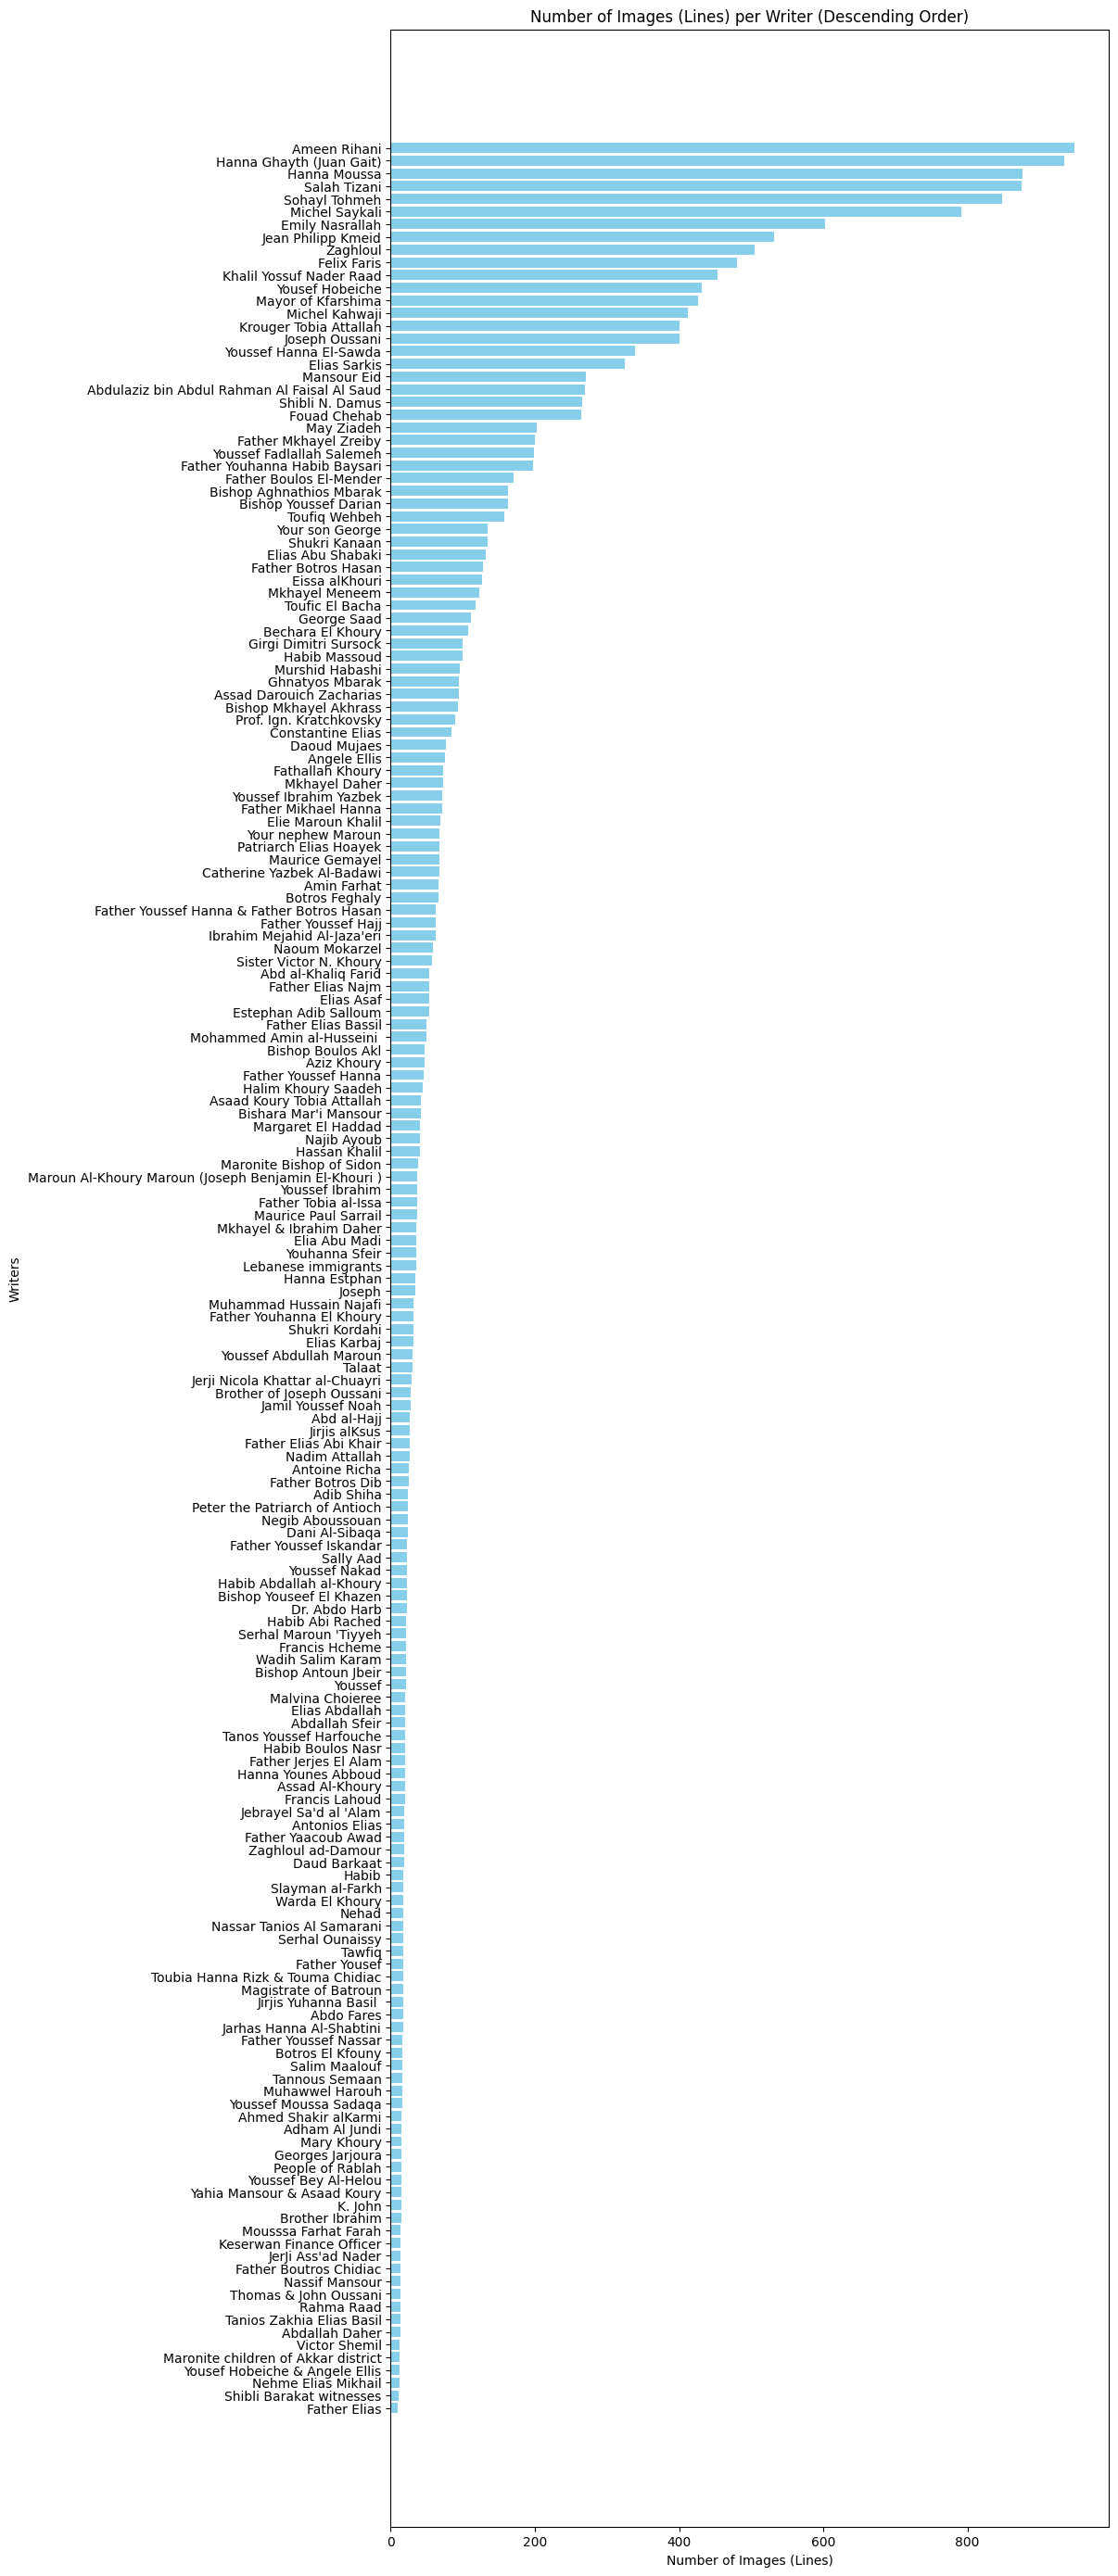

In [ ]:
# Example usage
csv_path = "/Users/hamza/Research/Muharaf/Dataset/merged_writer.csv"  # Path to your CSV file with writer data
base_folder = "/Users/hamza/Research/Muharaf/Dataset/Lines"      # Base folder containing image folders
list_writer_names_with_image_count(csv_path, base_folder)

In [ ]:
from PIL import Image

def count_images_in_folder(root_folder):
    image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp', '.tiff', '.webp')
    total_images = 0
    
    for subdir, _, files in os.walk(root_folder):
        for file in files:
            if file.lower().endswith(image_extensions):
                file_path = os.path.join(subdir, file)
                try:
                    with Image.open(file_path) as img:  # Validate it's an image
                        img.verify()
                    total_images += 1
                except Exception:
                    pass  # Skip non-image files or corrupted files

    return total_images

if __name__ == "__main__":
    folder_path = "/Users/hamza/Research/Muharaf/untitled folder/Lines"  # Replace with your folder path
    if os.path.isdir(folder_path):
        total_images = count_images_in_folder(folder_path)
        print(f"Total number of images: {total_images}")
    else:
        print("Invalid folder path. Please check the path and try again.")


Total number of images: 24495
